# EDA de Calidad e Integridad - Eje Logistico

Notebook de analisis exploratorio para `dataset_logistico.csv`, enfocado en calidad de datos, distribuciones, normalidad, relaciones entre variables y validacion de la logica operativa del abastecimiento.

## 1. Librerias

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Carga del dataset

In [92]:
RUTA_DATASET = "../../data/dataset_logistico_1.csv"

df = pd.read_csv(RUTA_DATASET)
df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Filas: 100,000
Columnas: 22


,dt,sale_amount,product_id,name_products,tipo_producto_app,store_id,first_category_id,second_category_id,third_category_id,discount,holiday_flag,activity_flag,mes,dia_mes,dia_semana,fin_semana,horas_con_stock,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1
0,2024-03-28,68.64,001,Metotrexato 500mg,Clinico,0,20,50,24,0.996,0,0,3,28,3,0,3,NaN,NaN,NaN,NaN,NaN
1,2024-03-29,67.59,001,Metotrexato 500mg,Clinico,0,20,50,24,0.997,0,0,3,29,4,0,0,68.64,NaN,68.6400,68.6400,3.0
2,2024-03-30,69.27,001,Metotrexato 500mg,Clinico,0,20,50,24,1.000,1,0,3,30,5,1,0,67.59,NaN,68.1150,68.1150,0.0
3,2024-03-31,69.23,001,Metotrexato 500mg,Clinico,0,20,50,24,0.999,1,0,3,31,6,1,2,69.27,NaN,68.5000,68.5000,0.0
4,2024-04-01,68.56,001,Metotrexato 500mg,Clinico,0,20,50,24,0.997,0,0,4,1,0,0,2,69.23,NaN,68.6825,68.6825,2.0


## 3. Analisis de calidad e integridad de los datos

In [93]:
df.info()

print("\nValores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))

print(f"\nFilas duplicadas: {df.duplicated().sum():,}")

print("\nResumen estadistico:")
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   dt                  100000 non-null  datetime64[us]
 1   sale_amount         100000 non-null  float64       
 2   product_id          100000 non-null  str           
 3   name_products       100000 non-null  str           
 4   tipo_producto_app   100000 non-null  str           
 5   store_id            100000 non-null  int64         
 6   first_category_id   100000 non-null  int64         
 7   second_category_id  100000 non-null  int64         
 8   third_category_id   100000 non-null  int64         
 9   discount            100000 non-null  float64       
 10  holiday_flag        100000 non-null  int64         
 11  activity_flag       100000 non-null  int64         
 12  mes                 100000 non-null  int64         
 13  dia_mes             100000 non-null  int6

,nulos
venta_lag_7,7784
venta_promedio_14d,1112
venta_promedio_7d,1112
venta_lag_1,1112
stock_lag_1,1112
dt,0
store_id,0
tipo_producto_app,0
name_products,0
product_id,0



Filas duplicadas: 0

Resumen estadistico:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
dt,100000,NaN,NaN,NaN,2024-05-11 11:54:14.400000,2024-03-28 00:00:00,2024-04-19 00:00:00,2024-05-11 00:00:00,2024-06-03 00:00:00,2024-06-25 00:00:00,NaN
sale_amount,100000.0,NaN,NaN,NaN,42.504576,14.11,29.58,41.12,55.07,70.0,15.398641
product_id,100000,273,010,1170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name_products,100000,273,Cateter Endovenoso 24G,1170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_producto_app,100000,3,Producto general,45640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,100000.0,NaN,NaN,NaN,19.0513,0.0,2.0,18.0,29.0,46.0,14.043854
first_category_id,100000.0,NaN,NaN,NaN,14.6905,0.0,4.0,16.0,21.0,31.0,8.943753
second_category_id,100000.0,NaN,NaN,NaN,44.0872,0.0,28.0,33.0,64.0,82.0,21.832622
third_category_id,100000.0,NaN,NaN,NaN,111.9406,0.0,66.0,105.0,167.0,232.0,60.44367
discount,100000.0,NaN,NaN,NaN,0.914588,0.358,0.851,0.988,1.0,1.0,0.113639


## 4. Auditoria de integridad: valores nulos y duplicados

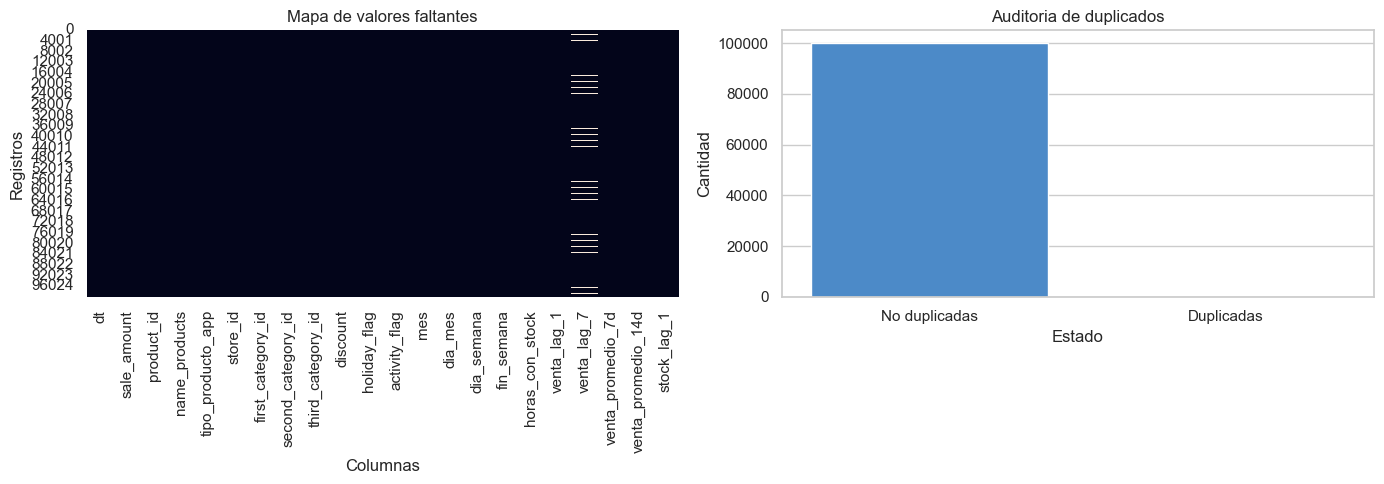

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df.isna(), cbar=False, ax=axes[0])
axes[0].set_title("Mapa de valores faltantes")
axes[0].set_xlabel("Columnas")
axes[0].set_ylabel("Registros")

duplicados = pd.DataFrame({
    "estado": ["No duplicadas", "Duplicadas"],
    "cantidad": [len(df) - df.duplicated().sum(), df.duplicated().sum()]
})
sns.barplot(data=duplicados, x="estado", y="cantidad", ax=axes[1], color="#378ADD")
axes[1].set_title("Auditoria de duplicados")
axes[1].set_xlabel("Estado")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

## 5. Composicion del inventario: cantidad de productos por categoria

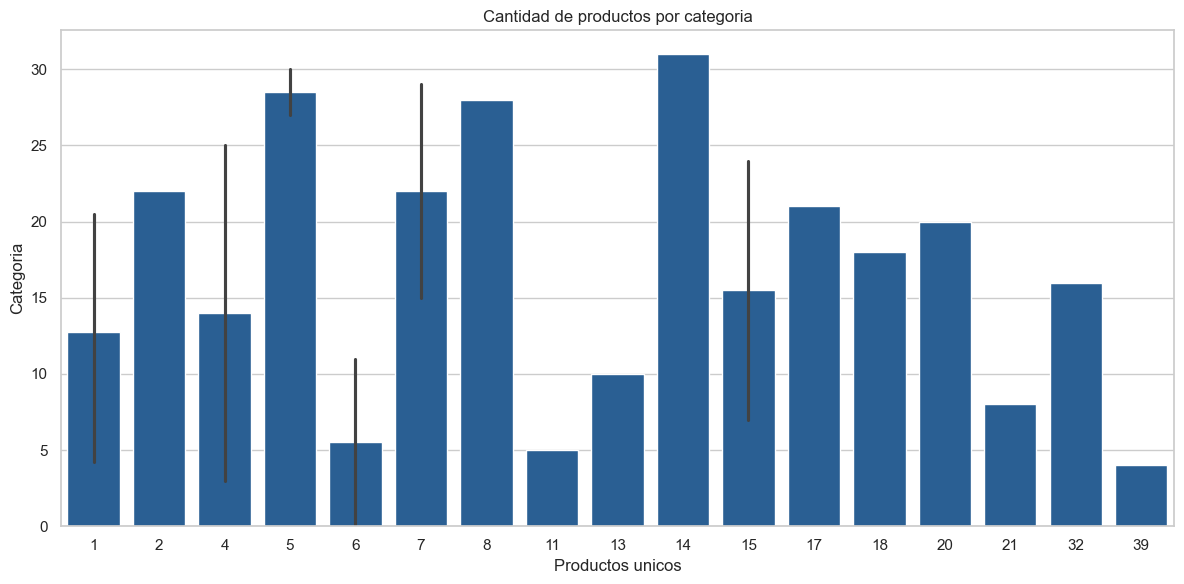

,first_category_id,productos_unicos
0,4,39
1,16,32
2,8,21
3,20,20
4,18,18
5,21,17
6,7,15
7,24,15
8,31,14
9,10,13


In [95]:
if "nombre_categoria_n1" in df.columns:
    col_categoria = "nombre_categoria_n1"
elif "first_category_id" in df.columns:
    col_categoria = "first_category_id"
elif "second_category_id" in df.columns:
    col_categoria = "second_category_id"
elif "third_category_id" in df.columns:
    col_categoria = "third_category_id"
else:
    col_categoria = None

if col_categoria is not None:
    conteo_categoria = (
        df.groupby(col_categoria, observed=True)["product_id"]
        .nunique()
        .sort_values(ascending=False)
        .reset_index(name="productos_unicos")
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=conteo_categoria, y=col_categoria, x="productos_unicos", color="#185FA5")
    plt.title("Cantidad de productos por categoria")
    plt.xlabel("Productos unicos")
    plt.ylabel("Categoria")
    plt.tight_layout()
    plt.show()

    display(conteo_categoria.head(20))

## 6. Analisis de distribuciones y normalidad

In [96]:
columnas_numericas = [
    "sale_amount",
    "discount",
    "horas_con_stock",
    "venta_lag_1",
    "venta_lag_7",
    "venta_promedio_7d",
    "venta_promedio_14d",
    "stock_lag_1",
]

columnas_numericas = [col for col in columnas_numericas if col in df.columns]
columnas_numericas

['sale_amount',
 'discount',
 'horas_con_stock',
 'venta_lag_1',
 'venta_lag_7',
 'venta_promedio_7d',
 'venta_promedio_14d',
 'stock_lag_1']

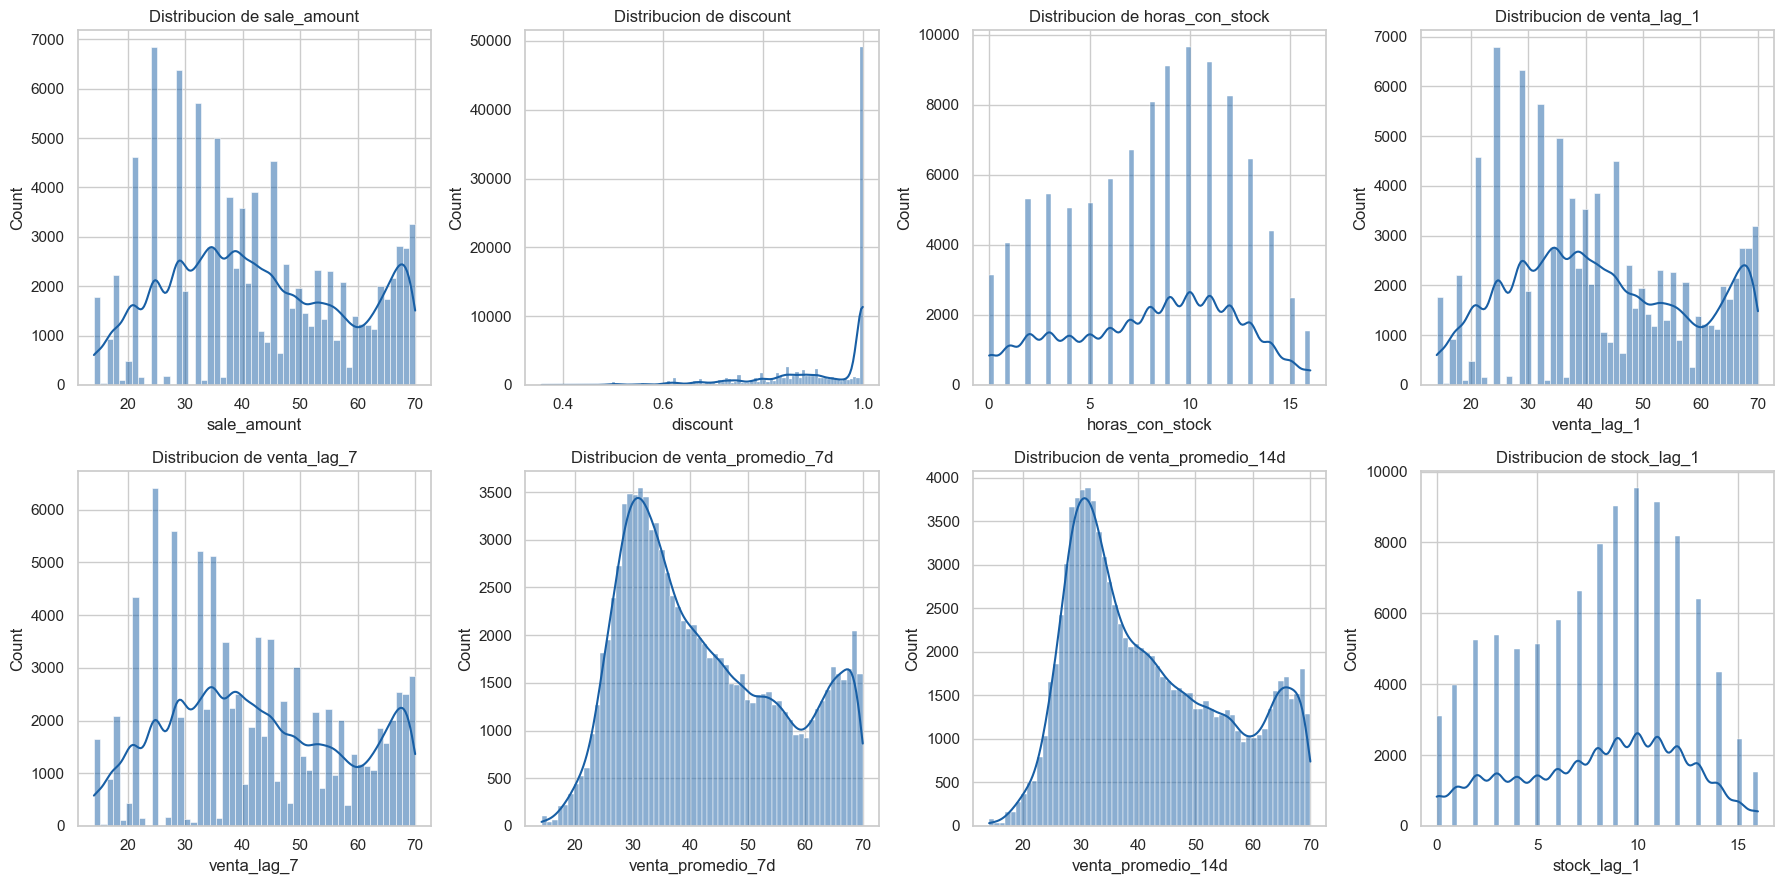

In [97]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#185FA5")
    axes[i].set_title(f"Distribucion de {col}")

for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [98]:
resultados_normalidad = []

for col in columnas_numericas:
    serie = df[col].dropna()
    muestra = serie.sample(min(len(serie), 5000), random_state=42) if len(serie) > 5000 else serie
    estadistico, p_valor = shapiro(muestra)
    resultados_normalidad.append({
        "variable": col,
        "estadistico_shapiro": estadistico,
        "p_valor": p_valor,
        "normal": "Si" if p_valor >= 0.05 else "No"
    })

df_normalidad = pd.DataFrame(resultados_normalidad).sort_values("p_valor")
display(df_normalidad)

,variable,estadistico_shapiro,p_valor,normal
1,discount,0.767504,1.819375e-64,No
6,venta_promedio_14d,0.940537,7.257968e-41,No
5,venta_promedio_7d,0.945628,1.646439e-39,No
4,venta_lag_7,0.958396,1.344457e-35,No
3,venta_lag_1,0.962411,3.599347e-34,No
0,sale_amount,0.964391,2.019000e-33,No
7,stock_lag_1,0.967882,5.114100e-32,No
2,horas_con_stock,0.968648,1.077194e-31,No


## 7. Deteccion de valores atipicos (boxplots)

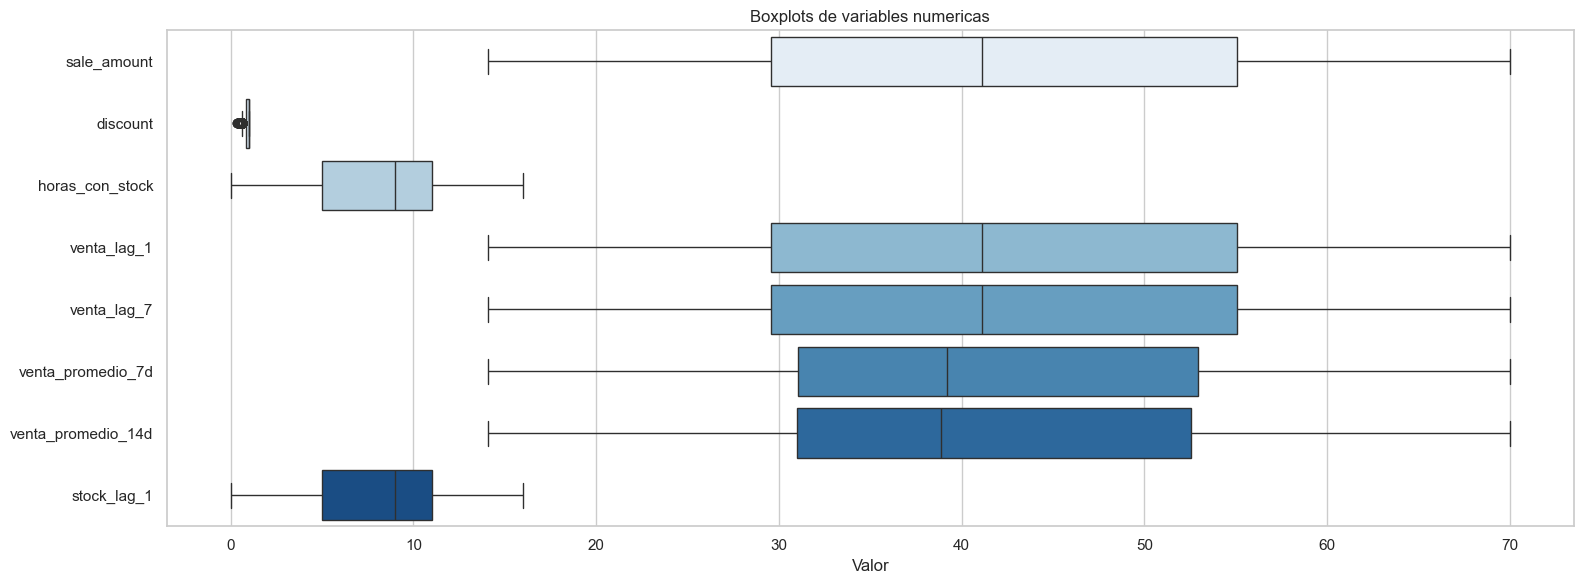

In [99]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df[columnas_numericas], orient="h", palette="Blues")
plt.title("Boxplots de variables numericas")
plt.xlabel("Valor")
plt.tight_layout()
plt.show()

## 8. Diagnostico temporal del suministro

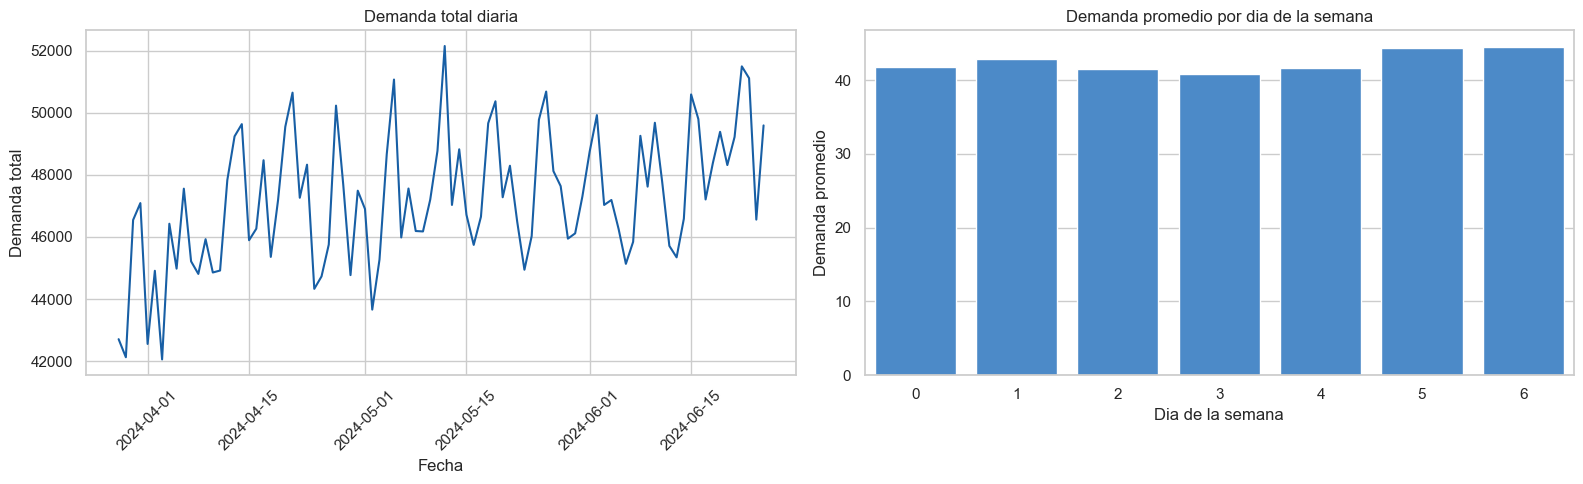

In [100]:
ventas_diarias = df.groupby("dt", as_index=False)["sale_amount"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=ventas_diarias, x="dt", y="sale_amount", ax=axes[0], color="#185FA5")
axes[0].set_title("Demanda total diaria")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Demanda total")
axes[0].tick_params(axis="x", rotation=45)

demanda_dia_semana = df.groupby("dia_semana", as_index=False)["sale_amount"].mean()
sns.barplot(data=demanda_dia_semana, x="dia_semana", y="sale_amount", ax=axes[1], color="#378ADD")
axes[1].set_title("Demanda promedio por dia de la semana")
axes[1].set_xlabel("Dia de la semana")
axes[1].set_ylabel("Demanda promedio")

plt.tight_layout()
plt.show()

## 9. Productos con mayor demanda por tipo

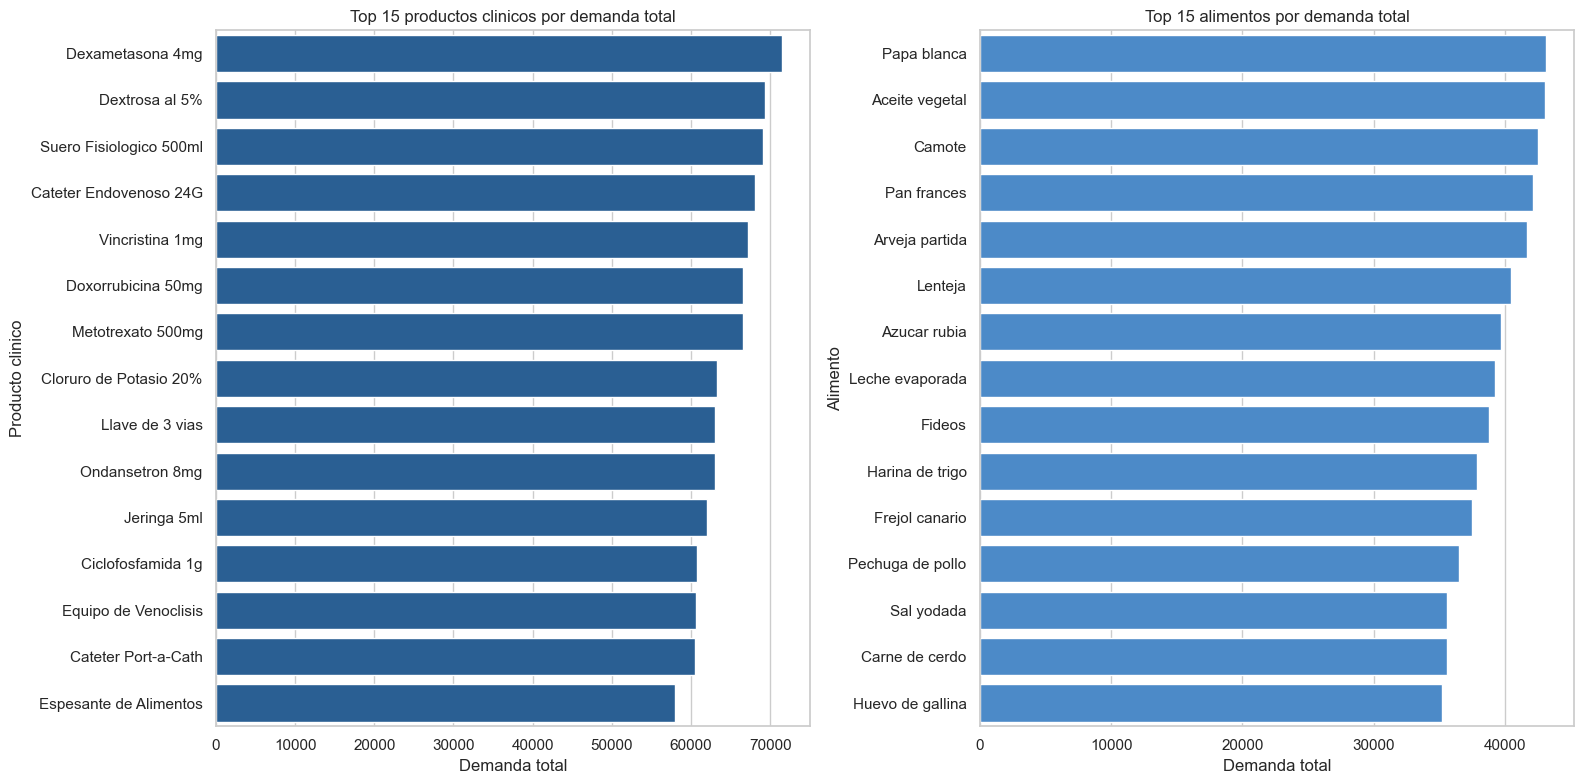

,product_id,name_products,sale_amount
0,006,Dexametasona 4mg,71432.05
1,008,Dextrosa al 5%,69285.24
2,007,Suero Fisiologico 500ml,69124.11
3,010,Cateter Endovenoso 24G,68122.14
4,003,Vincristina 1mg,67238.90
5,004,Doxorrubicina 50mg,66562.04
6,001,Metotrexato 500mg,66509.84
7,009,Cloruro de Potasio 20%,63274.54
8,014,Llave de 3 vias,63079.94
9,005,Ondansetron 8mg,62993.99


,product_id,name_products,sale_amount
0,036,Papa blanca,43114.30
1,042,Aceite vegetal,43074.48
2,037,Camote,42522.12
3,034,Pan frances,42142.35
4,041,Arveja partida,41657.11
5,039,Lenteja,40456.67
6,043,Azucar rubia,39745.10
7,045,Leche evaporada,39257.16
8,032,Fideos,38765.83
9,035,Harina de trigo,37853.74


In [101]:
df["tipo_producto_app"] = (
    df["tipo_producto_app"]
    .astype(str)
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("ascii")
)

top_productos_clinicos = (
    df[df["tipo_producto_app"].str.contains("Clinico", na=False)]
    .groupby(["product_id", "name_products"], observed=True)["sale_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

top_productos_alimentos = (
    df[df["tipo_producto_app"].str.contains("Alimento", na=False)]
    .groupby(["product_id", "name_products"], observed=True)["sale_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if not top_productos_clinicos.empty:
    sns.barplot(data=top_productos_clinicos, y="name_products", x="sale_amount", color="#185FA5", ax=axes[0])
    axes[0].set_ylabel("Producto clinico")
else:
    axes[0].text(0.5, 0.5, "No hay productos clinicos clasificados", ha="center", va="center")
    axes[0].set_axis_off()
axes[0].set_title("Top 15 productos clinicos por demanda total")
axes[0].set_xlabel("Demanda total")

if not top_productos_alimentos.empty:
    sns.barplot(data=top_productos_alimentos, y="name_products", x="sale_amount", color="#378ADD", ax=axes[1])
    axes[1].set_ylabel("Alimento")
else:
    axes[1].text(0.5, 0.5, "No hay alimentos clasificados", ha="center", va="center")
    axes[1].set_axis_off()
axes[1].set_title("Top 15 alimentos por demanda total")
axes[1].set_xlabel("Demanda total")

plt.tight_layout()
plt.show()

display(top_productos_clinicos)
display(top_productos_alimentos)

## 10. Analisis de relaciones, covarianza y dispersion

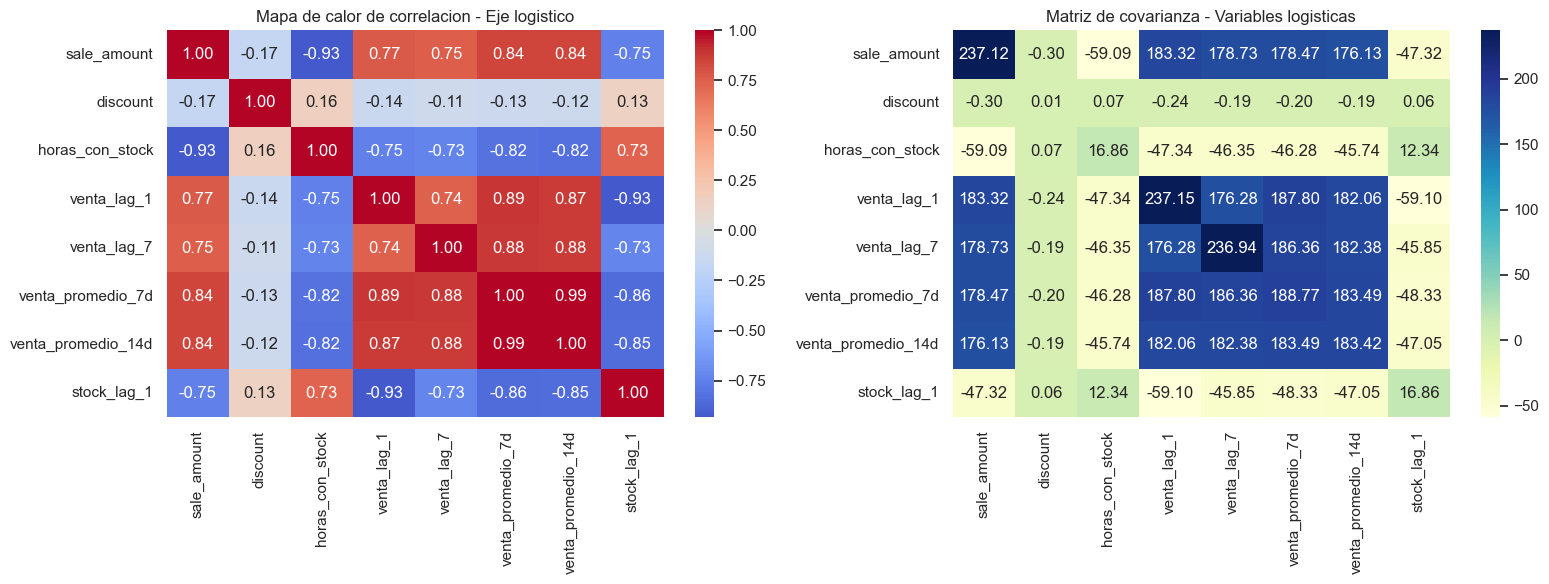

In [102]:
corr = df[columnas_numericas].corr(numeric_only=True)
cov = df[columnas_numericas].cov(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Mapa de calor de correlacion - Eje logistico")

sns.heatmap(cov, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Matriz de covarianza - Variables logisticas")

plt.tight_layout()
plt.show()

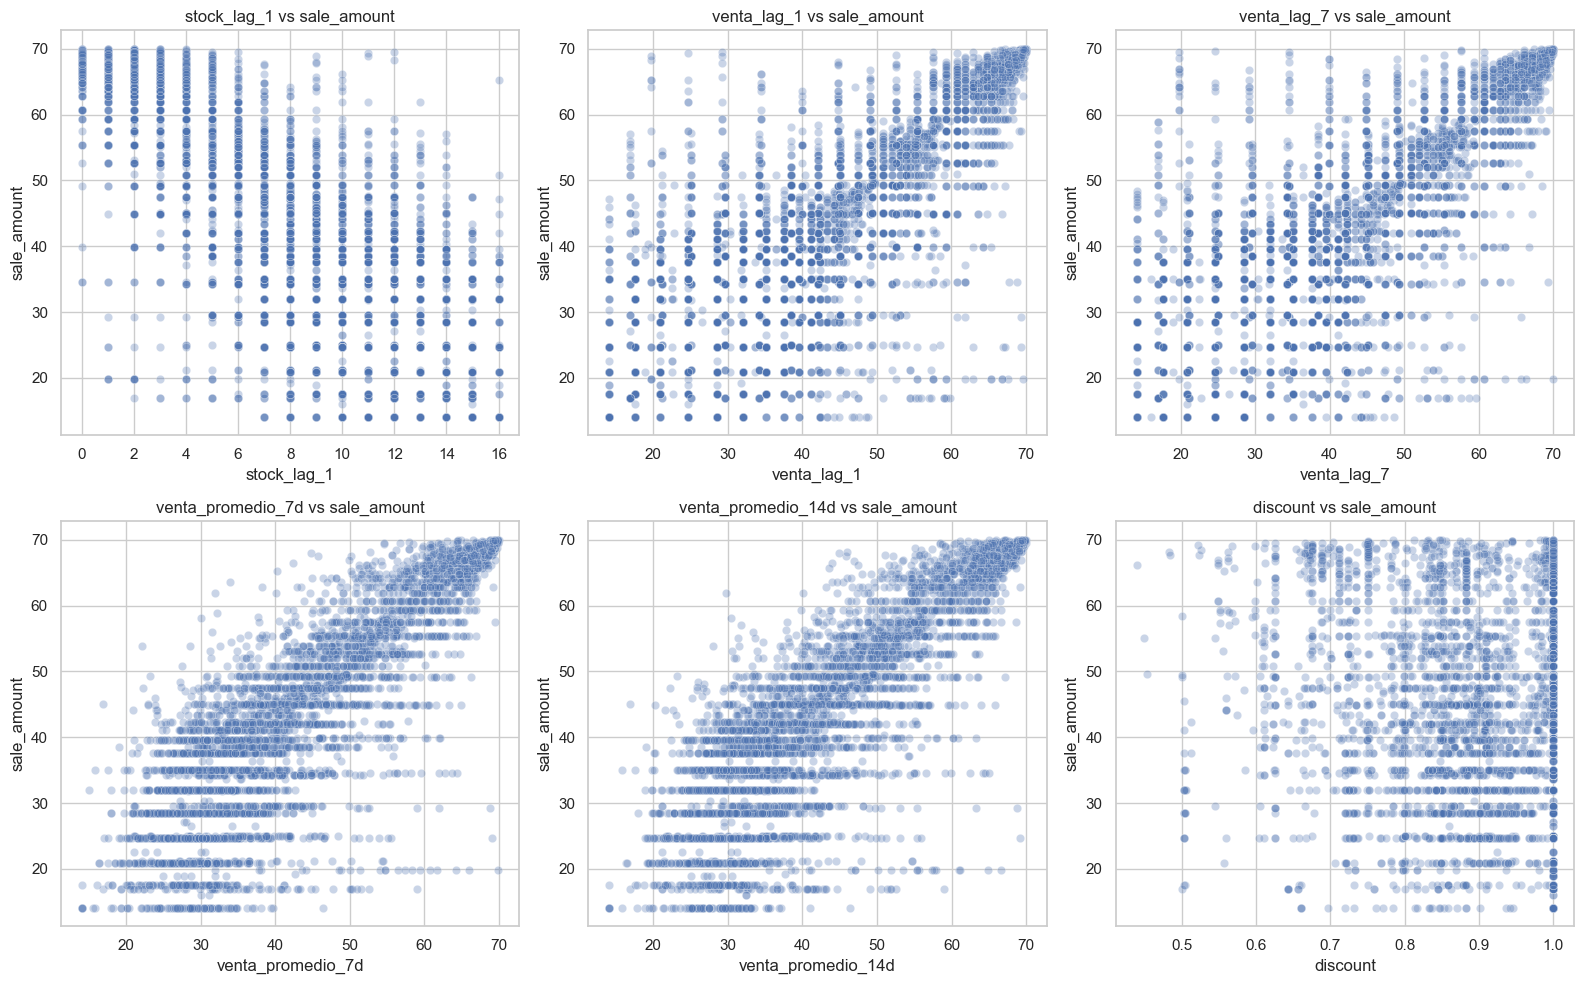

In [103]:
variables_predictoras = [
    "stock_lag_1",
    "venta_lag_1",
    "venta_lag_7",
    "venta_promedio_7d",
    "venta_promedio_14d",
    "discount",
]

variables_predictoras = [col for col in variables_predictoras if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(variables_predictoras):
    sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42), x=col, y="sale_amount", alpha=0.3, ax=axes[i])
    axes[i].set_title(f"{col} vs sale_amount")

for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

## 11. Stock, descuentos y eventos

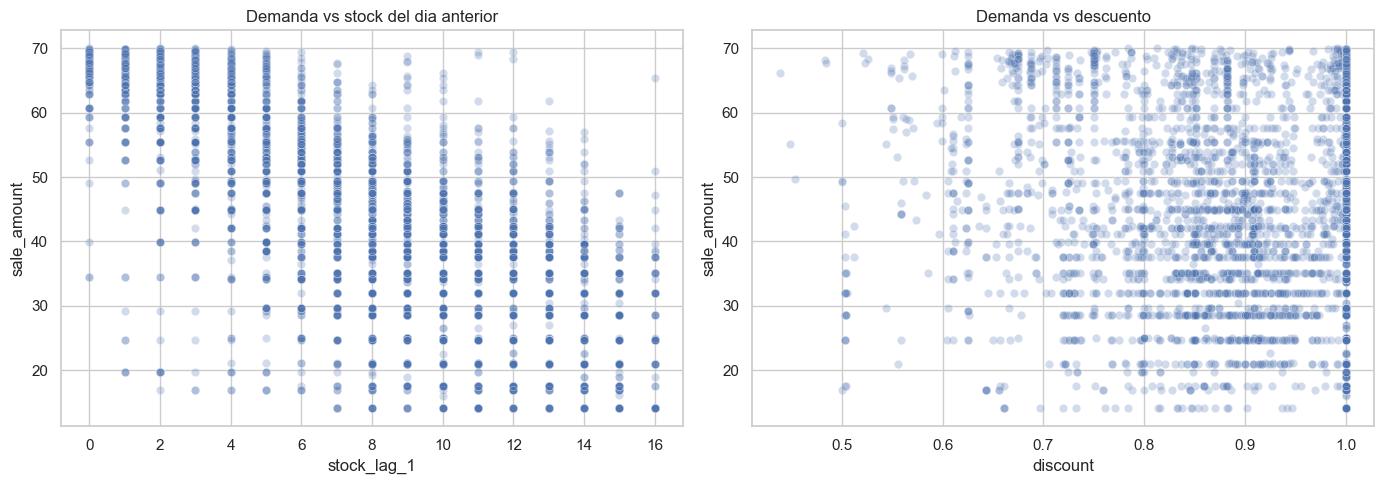

,count,mean,median,sum
holiday_flag,,,,
0,65554,41.730591,39.55,2735607.19
1,34446,43.977543,42.38,1514850.43


,count,mean,median,sum
activity_flag,,,,
0,60096,41.120492,38.45,2471177.07
1,39904,44.589027,43.38,1779280.55


In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42), x="stock_lag_1", y="sale_amount", alpha=0.25, ax=axes[0])
axes[0].set_title("Demanda vs stock del dia anterior")
axes[0].set_xlabel("stock_lag_1")
axes[0].set_ylabel("sale_amount")

sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42), x="discount", y="sale_amount", alpha=0.25, ax=axes[1])
axes[1].set_title("Demanda vs descuento")
axes[1].set_xlabel("discount")
axes[1].set_ylabel("sale_amount")

plt.tight_layout()
plt.show()

for col in ["holiday_flag", "activity_flag"]:
    if col in df.columns:
        display(df.groupby(col, observed=True)["sale_amount"].agg(["count", "mean", "median", "sum"]))

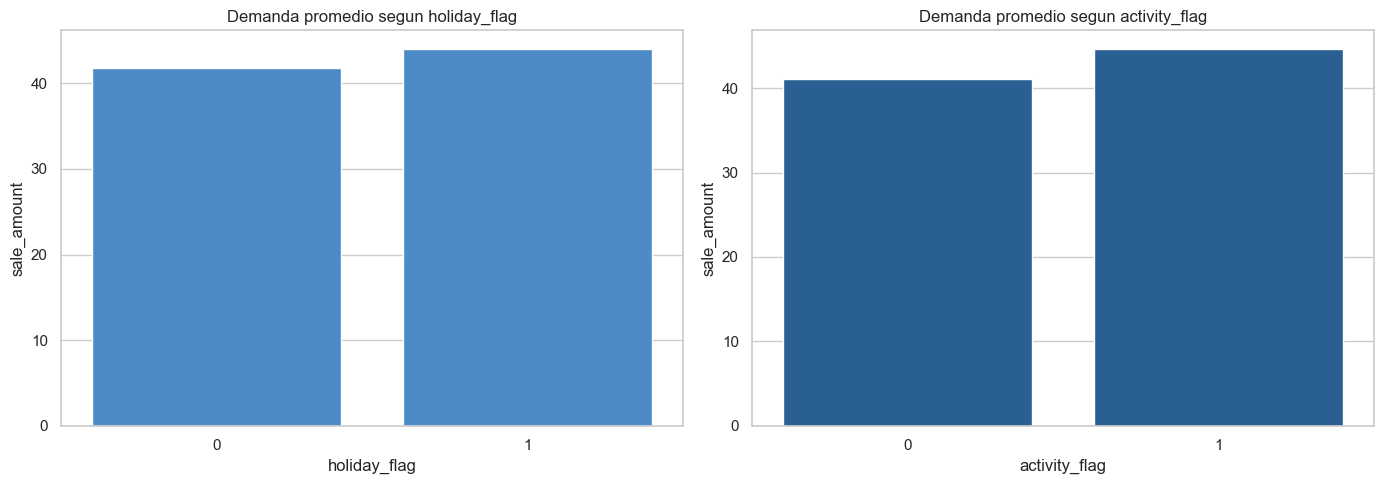

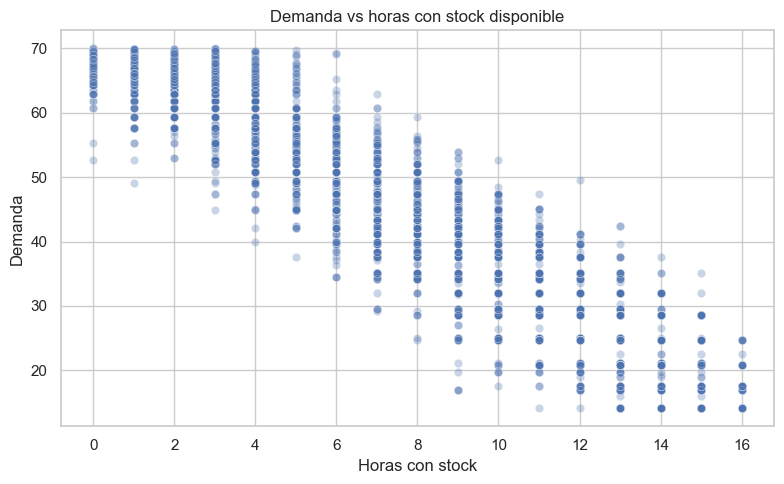

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df.groupby("holiday_flag", as_index=False)["sale_amount"].mean(), x="holiday_flag", y="sale_amount", ax=axes[0], color="#378ADD")
axes[0].set_title("Demanda promedio segun holiday_flag")

sns.barplot(data=df.groupby("activity_flag", as_index=False)["sale_amount"].mean(), x="activity_flag", y="sale_amount", ax=axes[1], color="#185FA5")
axes[1].set_title("Demanda promedio segun activity_flag")

plt.tight_layout()
plt.show()

if "horas_con_stock" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42), x="horas_con_stock", y="sale_amount", alpha=0.3)
    plt.title("Demanda vs horas con stock disponible")
    plt.xlabel("Horas con stock")
    plt.ylabel("Demanda")
    plt.tight_layout()
    plt.show()